## Notebook 4: Results Comparison and Validation

This notebook is the final step in our pipeline. The goal is to bring the results obtained from PCA and Differential Expression Analysis notebooks and compare them using Venn diagrams. By finding the overlap between these two methods, we can can check how many genes were commonly identified by the two methods.

---
### Data Source:

This notebook does not use the raw dataset directly. Instead, it uses the extracted gene lists generated in Notebook 3 (PCA) and Notebook 2 (Differential Expression Analysis).

* **PCA Gene List**: `top_pc_contributing_genes.csv`
* **DEA Gene List**: `top_100_dea_genes.csv`

---

In [ ]:
# Install matplotlib-venn in your system if it does not exist by default:
# !pip install matplotlib-venn

In [3]:
# importing libraries for data handling and visualisation
import pandas as pd
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Load the two gene lists into pandas DataFrames

# Load the list of top genes from PCA
pca_genes_df = pd.read_csv("top_pc_contributing_genes.csv")

# Load the list of significant genes from DEA
dea_genes_df = pd.read_csv("dea_top_100_gene_list.csv") 

# Display the first few rows of each DataFrame to confirm they loaded correctly
print("Top Genes from PCA:")
display(pca_genes_df)

print("\nTop Genes from Differential Expression Analysis:")
display(dea_genes_df)

Top Genes from PCA:


,Gene,PC4,abs_PC4
0,CCNA2,0.025429,0.025429
1,KIF2C,0.025338,0.025338
2,CCNB2,0.025306,0.025306
3,AURKB,0.025300,0.025300
4,TPX2,0.025228,0.025228
...,...,...,...
95,CENPI,0.022108,0.022108
96,KIF15,0.022032,0.022032
97,E2F1,0.022031,0.022031
98,CXCL10,0.022030,0.022030



Top Genes from Differential Expression Analysis:


,Gene,log2FoldChange,lfcSE,logCPM,stat,pvalue
0,ANXA9,3.850449,0.003655,4.881777,1600.141121,0.0
1,ABAT,3.413274,0.002729,6.305095,1770.913727,0.0
2,C6orf15,-5.947493,0.018758,2.085959,1882.117988,0.0
3,C5AR2,2.783648,0.002341,4.187570,1519.164331,0.0
4,CDC123,-0.976427,0.000447,5.746475,1700.351825,0.0
...,...,...,...,...,...,...
95,KRT81,-4.871831,0.012435,6.200164,1943.499972,0.0
96,FOXC1,-3.335239,0.002422,4.797960,4557.077097,0.0
97,DLGAP5,-2.319846,0.002972,3.063686,1678.560612,0.0
98,CTSC,-1.624777,0.001552,6.716092,1471.133875,0.0


In [12]:
# Extract the gene names from each DataFrame into a set
pca_gene_set = set(pca_genes_df['Gene'])
dea_gene_set = set(dea_genes_df['Gene'])

# Find the intersection of the two sets
overlapping_genes = pca_gene_set.intersection(dea_gene_set)

# Convert the set of overlapping genes to a list for easier viewing
overlapping_genes_list = list(overlapping_genes)

# Print the results
print(f"Number of overlapping genes: {len(overlapping_genes_list)}")

# convert the list into a dataframe so that we can view it as a table:
overlapping_genes_df = pd.DataFrame(overlapping_genes_list, columns=['Overlapping_Biomarker_Candidates'])
display(overlapping_genes_df)

# print("Overlapping genes:")
# print(overlapping_genes_list)

Number of overlapping genes: 15


,Overlapping_Biomarker_Candidates
0,ORC6
1,MKI67
2,TRIP13
3,FANCA
4,KPNA2
5,EXO1
6,PRR11
7,RRM2
8,SHCBP1
9,CCNA2


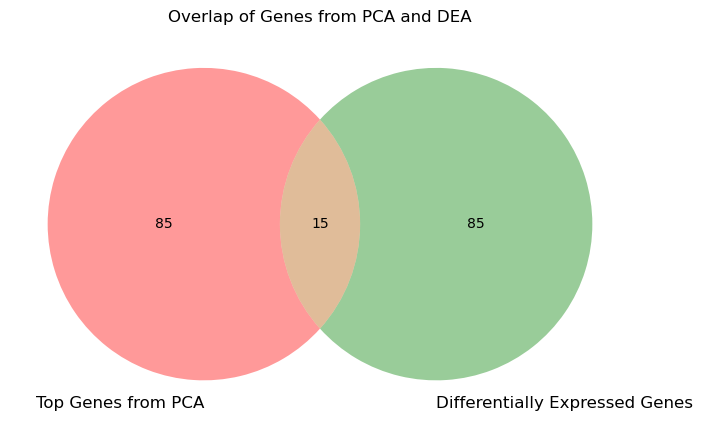

In [13]:
# Create a Venn diagram to visualise the overlap

plt.figure(figsize=(8, 8))
venn2(
    subsets=[pca_gene_set, dea_gene_set], 
    set_labels=('Top Genes from PCA', 'Differentially Expressed Genes')
)

plt.title("Overlap of Genes from PCA and DEA")
plt.show()

### Results:

We compared the top 100 genes from our PCA with the top 100 genes from our Differential Expression Analysis. The Venn diagram shows that **15 genes** were commonly identified by both methods.